# Name: Prathamesh Balaji Patil
# Roll: 11
# Div: TY A(AIML)
# Experiment No. 5
# Assignment

## Logistic Regression for Multiclass Classification


# Student Stress Level Prediction Using Multiclass Logistic Regression

## Aim
To develop a Machine Learning model using Multiclass Logistic Regression to predict the stress level of a student based on Study Hours, Sleep Hours, and Screen Time.

## Input Features
1. Study Hours
2. Sleep Hours
3. Screen Time

## Output Classes
- 0 = Low Stress
- 1 = Medium Stress
- 2 = High Stress


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import pickle

## Step 1: Create Dataset

In [2]:
data = {
    "Study_Hours": [
        2, 3, 4, 5, 6, 7, 8, 9, 10, 3,
        4, 5, 6, 7, 8, 9, 2, 3, 4, 5,
        6, 7, 8, 9, 10, 2, 4, 6, 8, 10,
        3, 5, 7, 9, 6, 4, 8, 5, 7, 9
    ],
    "Sleep_Hours": [
        9, 8, 8, 7, 7, 6, 6, 5, 4, 9,
        8, 7, 7, 6, 5, 4, 9, 8, 8, 7,
        6, 6, 5, 5, 4, 9, 8, 7, 5, 4,
        9, 7, 6, 5, 7, 8, 5, 7, 6, 5
    ],
    "Screen_Time": [
        2, 3, 3, 4, 5, 6, 7, 8, 9, 2,
        3, 4, 5, 6, 7, 9, 2, 3, 4, 5,
        6, 7, 8, 8, 10, 2, 3, 5, 8, 10,
        2, 4, 6, 9, 5, 3, 8, 4, 7, 9
    ],
    "Stress_Level": [
        0, 0, 0, 1, 1, 1, 2, 2, 2, 0,
        0, 1, 1, 1, 2, 2, 0, 0, 0, 1,
        1, 1, 2, 2, 2, 0, 0, 1, 2, 2,
        0, 1, 1, 2, 1, 0, 2, 1, 2, 2
    ]
}

df = pd.DataFrame(data)

print("Dataset Created Successfully!")
display(df)

Dataset Created Successfully!


,Study_Hours,Sleep_Hours,Screen_Time,Stress_Level
0,2,9,2,0
1,3,8,3,0
2,4,8,3,0
3,5,7,4,1
4,6,7,5,1
5,7,6,6,1
6,8,6,7,2
7,9,5,8,2
8,10,4,9,2
9,3,9,2,0


## Step 2: Data Exploration

In [3]:
print("First 5 Records:")
display(df.head())

print("\nLast 5 Records:")
display(df.tail())

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Dataset Shape:", df.shape)

First 5 Records:


,Study_Hours,Sleep_Hours,Screen_Time,Stress_Level
0,2,9,2,0
1,3,8,3,0
2,4,8,3,0
3,5,7,4,1
4,6,7,5,1



Last 5 Records:


,Study_Hours,Sleep_Hours,Screen_Time,Stress_Level
35,4,8,3,0
36,8,5,8,2
37,5,7,4,1
38,7,6,7,2
39,9,5,9,2



Number of Rows: 40
Number of Columns: 4
Dataset Shape: (40, 4)


In [4]:
print("Dataset Information:")
df.info()

print("\nStatistical Description:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Study_Hours   40 non-null     int64
 1   Sleep_Hours   40 non-null     int64
 2   Screen_Time   40 non-null     int64
 3   Stress_Level  40 non-null     int64
dtypes: int64(4)
memory usage: 1.4 KB

Statistical Description:


,Study_Hours,Sleep_Hours,Screen_Time,Stress_Level
count,40.000000,40.000000,40.000000,40.000000
mean,6.075000,6.550000,5.525000,1.050000
std,2.411378,1.551674,2.490881,0.814925
min,2.000000,4.000000,2.000000,0.000000
25%,4.000000,5.000000,3.000000,0.000000
50%,6.000000,7.000000,5.000000,1.000000
75%,8.000000,8.000000,8.000000,2.000000
max,10.000000,9.000000,10.000000,2.000000


## Step 3: Data Preprocessing

In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nNumber of Duplicate Records:")
print(df.duplicated().sum())

Missing Values:
Study_Hours     0
Sleep_Hours     0
Screen_Time     0
Stress_Level    0
dtype: int64

Number of Duplicate Records:
20


In [6]:
stress_labels = {
    0: "Low Stress",
    1: "Medium Stress",
    2: "High Stress"
}

df["Stress_Category"] = df["Stress_Level"].map(stress_labels)

print("Stress Level Distribution:")
print(df["Stress_Category"].value_counts())

Stress Level Distribution:
Stress_Category
Medium Stress    14
High Stress      14
Low Stress       12
Name: count, dtype: int64


## Step 4: Data Visualization

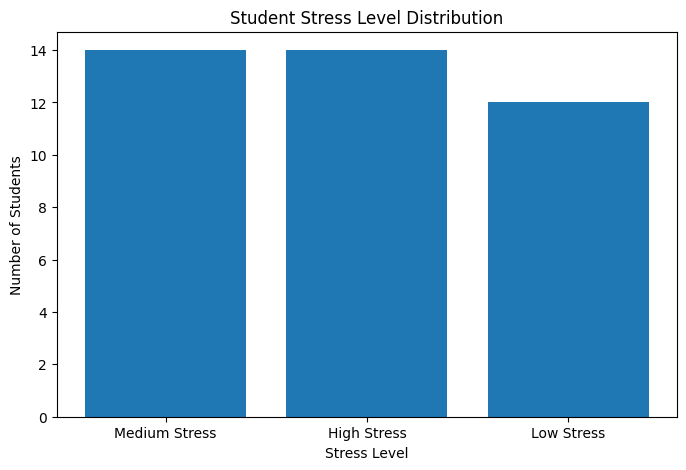

In [7]:
stress_counts = df["Stress_Category"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(stress_counts.index, stress_counts.values)
plt.title("Student Stress Level Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")
plt.show()

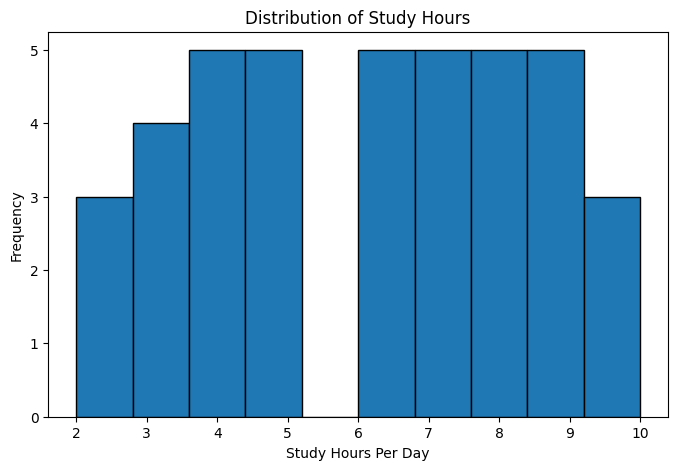

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["Study_Hours"], bins=10, edgecolor="black")
plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Frequency")
plt.show()

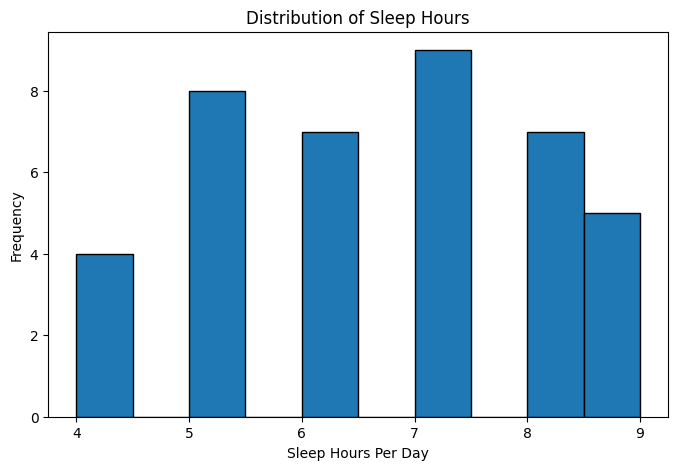

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["Sleep_Hours"], bins=10, edgecolor="black")
plt.title("Distribution of Sleep Hours")
plt.xlabel("Sleep Hours Per Day")
plt.ylabel("Frequency")
plt.show()

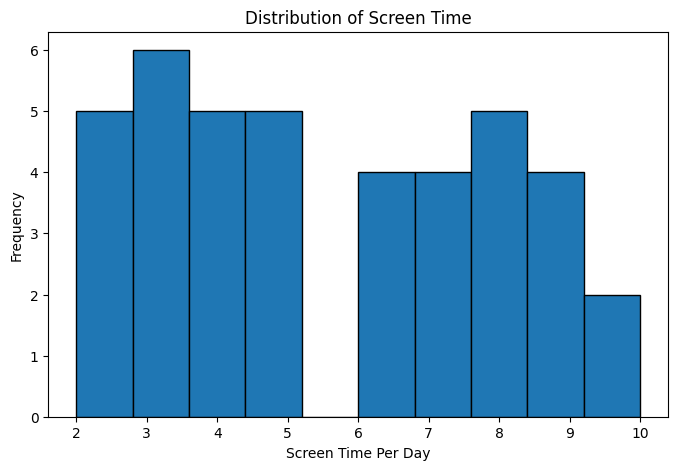

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["Screen_Time"], bins=10, edgecolor="black")
plt.title("Distribution of Screen Time")
plt.xlabel("Screen Time Per Day")
plt.ylabel("Frequency")
plt.show()

## Step 5: Define Features and Target Variable

In [11]:
X = df[[
    "Study_Hours",
    "Sleep_Hours",
    "Screen_Time"
]]

y = df["Stress_Level"]

print("Input Features:")
display(X.head())

print("\nTarget Variable:")
print(y.head())

Input Features:


,Study_Hours,Sleep_Hours,Screen_Time
0,2,9,2
1,3,8,3
2,4,8,3
3,5,7,4
4,6,7,5



Target Variable:
0    0
1    0
2    0
3    1
4    1
Name: Stress_Level, dtype: int64


## Step 6: Split Dataset into Training and Testing Data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (32, 3)
Testing Data Shape: (8, 3)


## Step 7: Create Multiclass Logistic Regression Model

In [13]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Multiclass Logistic Regression Model Created Successfully!")

Multiclass Logistic Regression Model Created Successfully!


## Step 8: Train the Model

In [14]:
model.fit(X_train, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


## Step 9: Make Predictions

In [15]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[0 1 1 2 1 2 0 2]

Predicted Values:
[0 1 1 2 1 2 0 2]


In [16]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Actual_Label"] = comparison["Actual"].map(stress_labels)
comparison["Predicted_Label"] = comparison["Predicted"].map(stress_labels)

display(comparison)

,Actual,Predicted,Actual_Label,Predicted_Label
0,0,0,Low Stress,Low Stress
1,1,1,Medium Stress,Medium Stress
2,1,1,Medium Stress,Medium Stress
3,2,2,High Stress,High Stress
4,1,1,Medium Stress,Medium Stress
5,2,2,High Stress,High Stress
6,0,0,Low Stress,Low Stress
7,2,2,High Stress,High Stress


## Step 10: Evaluate Model Performance

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 100.0 %


In [18]:
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    target_names=[
        "Low Stress",
        "Medium Stress",
        "High Stress"
    ],
    zero_division=0
))

               precision    recall  f1-score   support

   Low Stress       1.00      1.00      1.00         2
Medium Stress       1.00      1.00      1.00         3
  High Stress       1.00      1.00      1.00         3

     accuracy                           1.00         8
    macro avg       1.00      1.00      1.00         8
 weighted avg       1.00      1.00      1.00         8



Confusion Matrix:
[[2 0 0]
 [0 3 0]
 [0 0 3]]


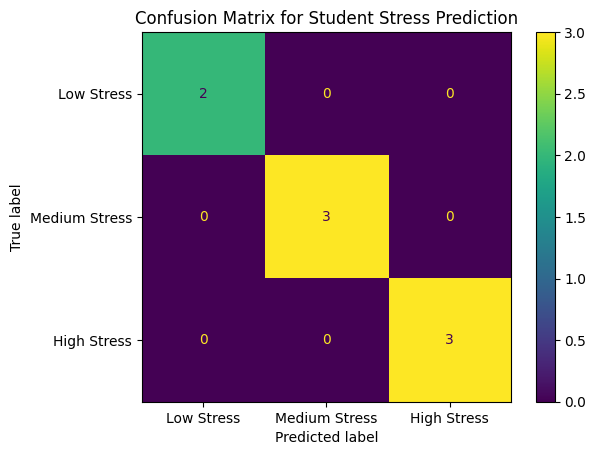

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1, 2]
)

print("Confusion Matrix:")
print(cm)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Low Stress",
        "Medium Stress",
        "High Stress"
    ]
)

display_cm.plot()
plt.title("Confusion Matrix for Student Stress Prediction")
plt.show()

## Step 11: Test the Model with Custom Student Data

In [20]:
new_student = pd.DataFrame(
    [[8, 5, 8]],
    columns=[
        "Study_Hours",
        "Sleep_Hours",
        "Screen_Time"
    ]
)

prediction = model.predict(new_student)

predicted_class = int(prediction[0])
result = stress_labels[predicted_class]

print("Student Data:")
display(new_student)

print("Predicted Stress Level:", result)

Student Data:


,Study_Hours,Sleep_Hours,Screen_Time
0,8,5,8


Predicted Stress Level: High Stress


In [21]:
test_students = pd.DataFrame(
    [
        [3, 8, 3],
        [6, 7, 5],
        [9, 4, 9]
    ],
    columns=[
        "Study_Hours",
        "Sleep_Hours",
        "Screen_Time"
    ]
)

predictions = model.predict(test_students)

test_students["Predicted_Stress_Level"] = [
    stress_labels[int(x)]
    for x in predictions
]

display(test_students)

,Study_Hours,Sleep_Hours,Screen_Time,Predicted_Stress_Level
0,3,8,3,Low Stress
1,6,7,5,Medium Stress
2,9,4,9,High Stress


## Step 12: Save the Trained Model

In [22]:
with open("StressModel.pkl", "wb") as file:
    pickle.dump(model, file)

print("StressModel.pkl saved successfully!")

StressModel.pkl saved successfully!


## Step 13: Download the Model

Run the next cell only in Google Colab to download `StressModel.pkl`.

In [23]:
try:
    from google.colab import files
    files.download("StressModel.pkl")
except ImportError:
    print("This cell is intended for Google Colab. StressModel.pkl has been saved successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

A Multiclass Logistic Regression model was successfully developed to predict student stress levels based on Study Hours, Sleep Hours, and Screen Time.

The model classifies students into:
- Low Stress
- Medium Stress
- High Stress

The dataset was explored for missing values and duplicate records. Visualizations were created to understand the data distribution. The data was divided into training and testing sets, standardized using StandardScaler, and trained using Logistic Regression.

The model was evaluated using accuracy score, classification report, and confusion matrix. Finally, the trained model was saved as `StressModel.pkl`, which can be integrated into a Flask web application for real-time prediction.


# Flask Code

In [ ]:
from flask import Flask, render_template, request
import pickle
import pandas as pd

# Create Flask application
app = Flask(__name__)


# Load the trained machine learning model
with open("StressModel.pkl", "rb") as file:
    model = pickle.load(file)


# Stress level labels
stress_labels = {
    0: "Low Stress",
    1: "Medium Stress",
    2: "High Stress"
}


# Home page
@app.route("/")
def home():
    return render_template("index.html")


# Prediction route
@app.route("/predict", methods=["POST"])
def predict():

    try:
        # Get values from the HTML form
        study_hours = float(request.form["study_hours"])
        sleep_hours = float(request.form["sleep_hours"])
        screen_time = float(request.form["screen_time"])


        # Input validation
        if study_hours < 0 or study_hours > 24:
            return render_template(
                "index.html",
                prediction_text="Study hours must be between 0 and 24."
            )


        if sleep_hours < 0 or sleep_hours > 24:
            return render_template(
                "index.html",
                prediction_text="Sleep hours must be between 0 and 24."
            )


        if screen_time < 0 or screen_time > 24:
            return render_template(
                "index.html",
                prediction_text="Screen time must be between 0 and 24."
            )


        # Create DataFrame with EXACT column names
        # used during model training in Colab
        input_data = pd.DataFrame(
            [[
                study_hours,
                sleep_hours,
                screen_time
            ]],
            columns=[
                "Study_Hours",
                "Sleep_Hours",
                "Screen_Time"
            ]
        )


        # Predict stress level
        prediction = model.predict(input_data)


        # Convert numerical prediction into text
        predicted_class = int(prediction[0])

        result = stress_labels.get(
            predicted_class,
            "Unknown"
        )


        # Display result
        return render_template(
            "index.html",
            prediction_text=f"Predicted Stress Level: {result}"
        )


    except ValueError:
        return render_template(
            "index.html",
            prediction_text="Please enter valid numerical values."
        )


    except Exception as e:
        return render_template(
            "index.html",
            prediction_text=f"Error: {str(e)}"
        )


# Run Flask application
if __name__ == "__main__":
    app.run(debug=True)

# Html Code

In [ ]:
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Student Stress Level Predictor</title>

    <style>

        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
            font-family: Arial, Helvetica, sans-serif;
        }


        body {
            min-height: 100vh;
            display: flex;
            justify-content: center;
            align-items: center;
            padding: 20px;

            background: linear-gradient(
                135deg,
                #eef2ff,
                #e0f2fe,
                #f5f3ff
            );
        }


        .container {
            width: 520px;
            max-width: 100%;
            background: white;
            padding: 40px;
            border-radius: 20px;

            box-shadow:
                0px 15px 35px
                rgba(0, 0, 0, 0.15);
        }


        .icon {
            width: 75px;
            height: 75px;
            margin: auto;
            border-radius: 50%;

            display: flex;
            justify-content: center;
            align-items: center;

            font-size: 35px;

            background: #4f46e5;
        }


        h1 {
            text-align: center;
            margin-top: 20px;
            color: #312e81;
            font-size: 28px;
        }


        .subtitle {
            text-align: center;
            margin-top: 10px;
            margin-bottom: 30px;
            color: #666;
            font-size: 15px;
        }


        label {
            display: block;
            margin-top: 18px;
            margin-bottom: 8px;
            font-weight: bold;
            color: #333;
        }


        input {
            width: 100%;
            padding: 14px;

            border: 1px solid #cbd5e1;

            border-radius: 10px;

            font-size: 16px;
        }


        input:focus {
            outline: none;

            border-color: #4f46e5;

            box-shadow:
                0 0 0 3px
                rgba(79, 70, 229, 0.12);
        }


        .info {
            margin-top: 6px;
            font-size: 12px;
            color: #777;
        }


        button {
            width: 100%;
            padding: 15px;
            margin-top: 30px;

            border: none;
            border-radius: 10px;

            background: #4f46e5;

            color: white;

            font-size: 17px;

            font-weight: bold;

            cursor: pointer;

            transition: 0.3s;
        }


        button:hover {
            background: #3730a3;

            transform: translateY(-2px);
        }


        .result {
            margin-top: 25px;
            padding: 18px;
            border-radius: 10px;

            text-align: center;

            background: #f0fdf4;

            border: 1px solid #bbf7d0;

            color: #166534;

            font-size: 18px;

            font-weight: bold;
        }


        footer {
            text-align: center;
            margin-top: 25px;
            color: #777;
            font-size: 12px;
        }

    </style>

</head>


<body>


<div class="container">


    <div class="icon">
        🧠
    </div>


    <h1>
        Student Stress Level Predictor
    </h1>


    <p class="subtitle">
        Predict student stress level using Multiclass Logistic Regression
    </p>


    <form action="/predict" method="POST">


        <label>
            Study Hours Per Day
        </label>

        <input
            type="number"
            name="study_hours"
            step="0.1"
            min="0"
            max="24"
            placeholder="Example: 6"
            required
        >

        <p class="info">
            Enter average study hours per day.
        </p>



        <label>
            Sleep Hours Per Day
        </label>

        <input
            type="number"
            name="sleep_hours"
            step="0.1"
            min="0"
            max="24"
            placeholder="Example: 7"
            required
        >

        <p class="info">
            Enter average sleep hours per day.
        </p>



        <label>
            Screen Time Per Day
        </label>

        <input
            type="number"
            name="screen_time"
            step="0.1"
            min="0"
            max="24"
            placeholder="Example: 5"
            required
        >

        <p class="info">
            Enter average screen time per day.
        </p>



        <button type="submit">
            Predict Stress Level
        </button>


    </form>


    {% if prediction_text %}

        <div class="result">
            {{ prediction_text }}
        </div>

    {% endif %}


    <footer>
        Machine Learning Based Student Stress Prediction System
    </footer>


</div>


</body>

</html>